    year  month  avg_temperature  rainfall_mm  humidity_percent  \
0   2020      1         5.993428    48.617357         63.238443   
1   2020      2         5.871439    27.658630         77.896064   
2   2020      3         9.061051    20.784584         75.003420   
3   2020      4        15.483925     0.000000         71.375411   
4   2020      5        17.974338    18.501457         72.780388   
5   2020      6        26.591552    27.742237         70.337641   
6   2020      7        23.911235    51.109226         54.245032   
7   2020      8        22.458977    67.083063         46.991467   
8   2020      9        19.973006    74.063907         46.792216   
9   2020     10        15.417727    70.403299         33.359070   
10  2020     11        11.476933    86.354699         42.101251   
11  2020     12         3.382702    62.801558         47.696806   
12  2021      1         5.687237    32.369598         61.620420   
13  2021      2         4.985902    36.116763         75.15499

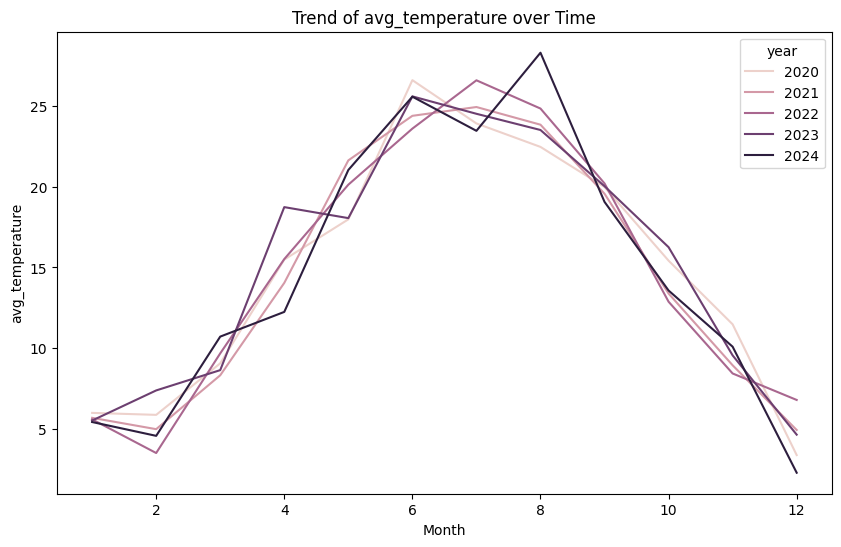

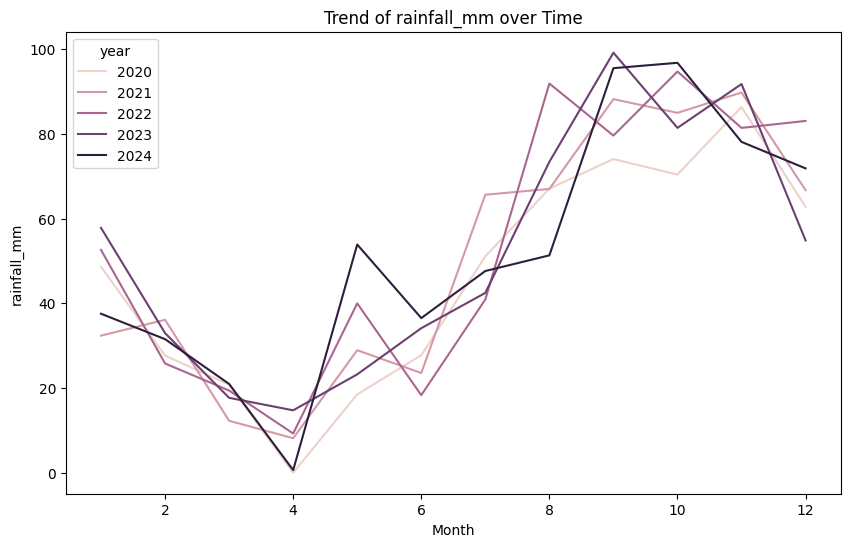

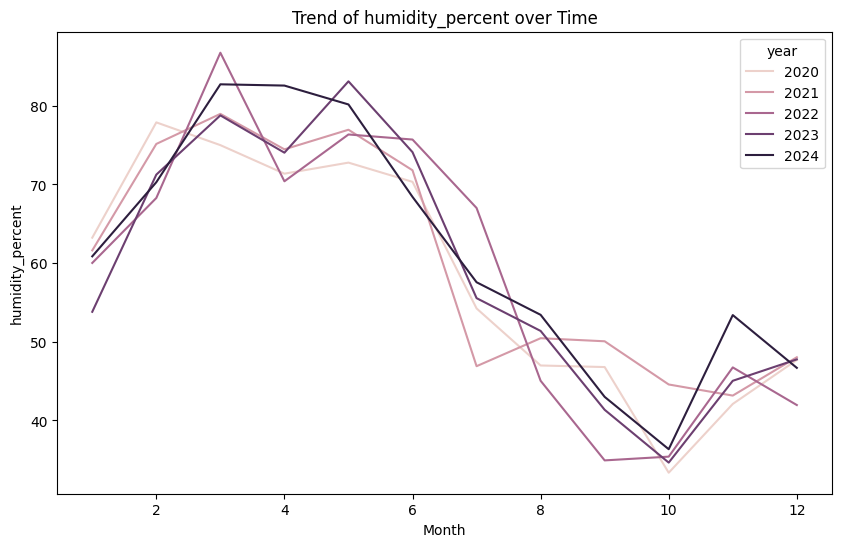

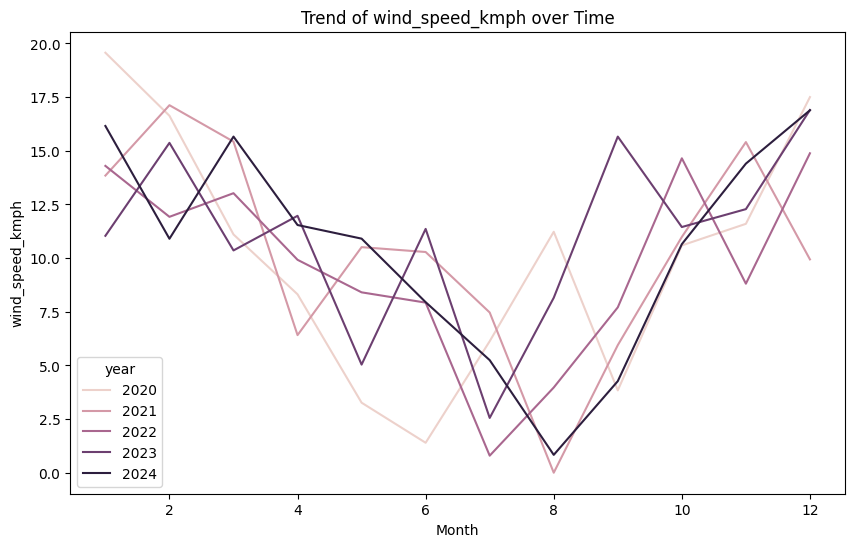

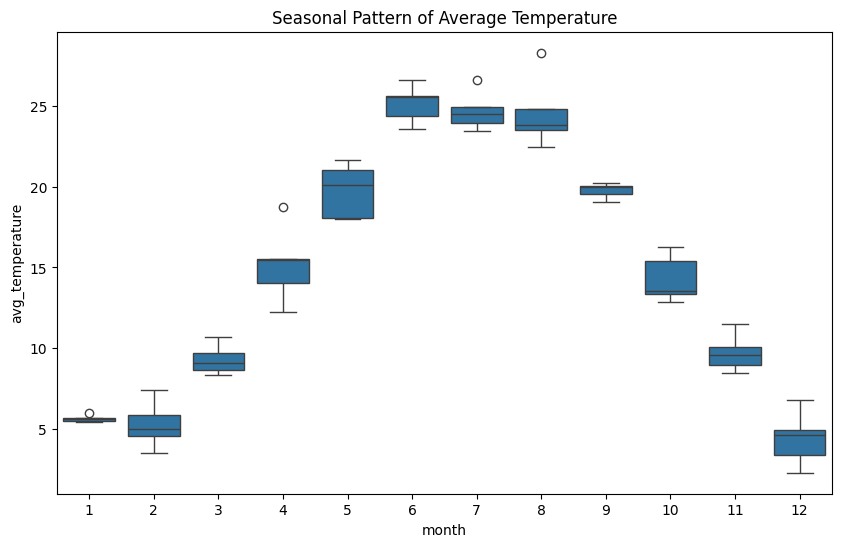

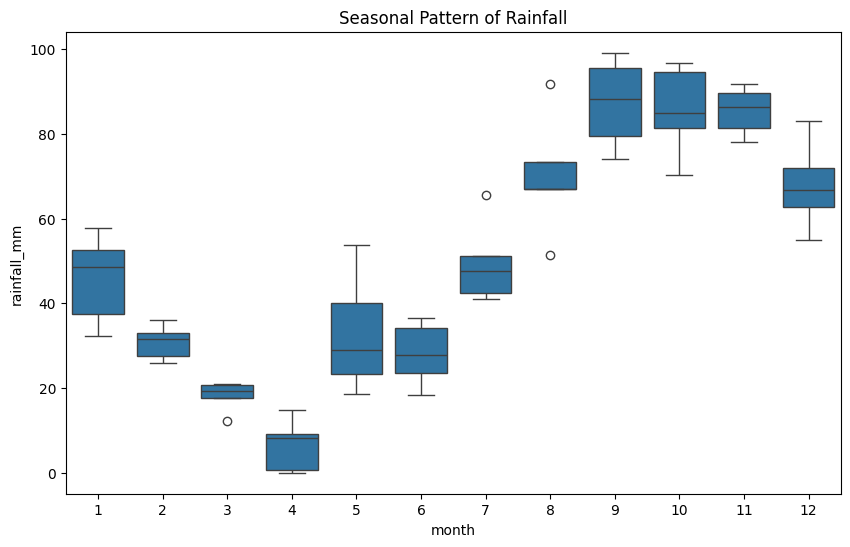

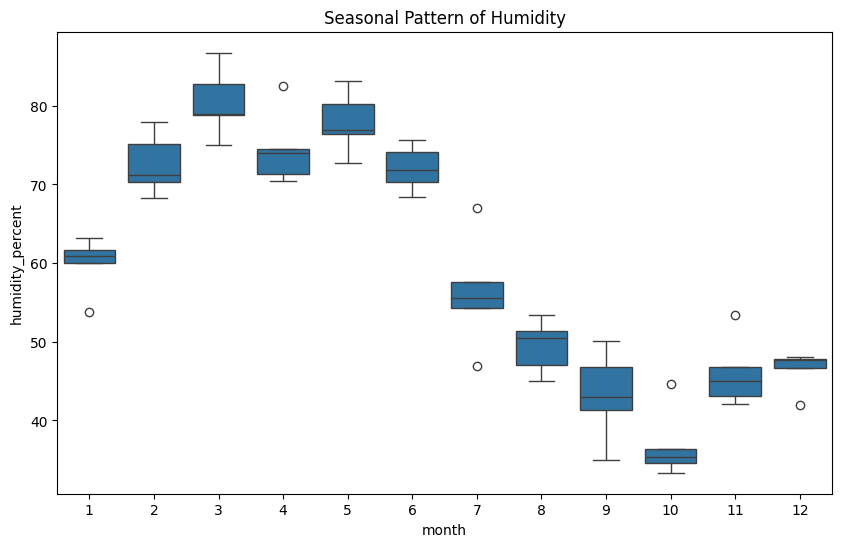

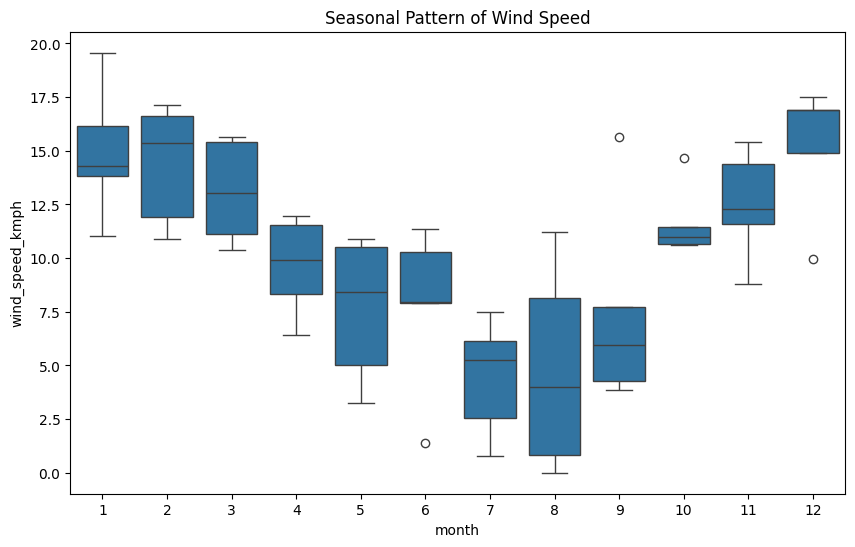

    month  avg_temperature  rainfall_mm  humidity_percent  wind_speed_kmph
0       1               10           20                65               11
1       2               12           30                70               10
2       3               15           40                75               12
3       4               19           70                80               14
4       5               22           90                85               15
5       6               25          120                90               13
6       7               26          110                88               11
7       8               25           80                85               10
8       9               22           60                80                9
9      10               19           50                75               10
10     11               15           30                70               10
11     12               12           20                65               11

Predictions for 2025 are

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate synthetic weather data
np.random.seed(42)  # for reproducibility
years = range(2020, 2025)
months = range(1, 13)
data = []

for year in years:
    for month in months:
        temp = 15 + 10 * np.sin(2 * np.pi * (month - 4) / 12) + np.random.normal(0, 2)  # Seasonal temperature
        rainfall = 50 + 40 * np.sin(2 * np.pi * (month - 7) / 12) + np.random.normal(0, 10) # Seasonal rainfall
        rainfall = max(0, rainfall) # Rainfall can't be negative
        humidity = 60 + 20 * np.sin(2 * np.pi * (month - 1) / 12) + np.random.normal(0, 5)
        humidity = max(0, min(100, humidity)) # Humidity between 0-100%
        wind_speed = 10 + 5 * np.sin(2 * np.pi * (month - 10) / 12) + np.random.normal(0, 3)
        wind_speed = max(0,wind_speed) # Wind speed can't be negative
        data.append([year, month, temp, rainfall, humidity, wind_speed])

df = pd.DataFrame(data, columns=['year', 'month', 'avg_temperature', 'rainfall_mm', 'humidity_percent', 'wind_speed_kmph'])

# 2. Load, display, and plot
print(df)


# Plotting trends
for col in ['avg_temperature', 'rainfall_mm', 'humidity_percent', 'wind_speed_kmph']:
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='month', y=col, hue='year', data=df)
    plt.title(f'Trend of {col} over Time')
    plt.xlabel('Month')
    plt.ylabel(col)
    plt.show()

# Seasonal patterns
plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='avg_temperature', data=df)
plt.title('Seasonal Pattern of Average Temperature')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x = 'month', y = 'rainfall_mm', data = df)
plt.title('Seasonal Pattern of Rainfall')
plt.show()

plt.figure(figsize = (10,6))
sns.boxplot(x = 'month', y = 'humidity_percent', data = df)
plt.title('Seasonal Pattern of Humidity')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x = 'month', y = 'wind_speed_kmph', data = df)
plt.title('Seasonal Pattern of Wind Speed')
plt.show()


# 3 & 4. Manual predictions for 2025 (based on visual inspection of plots)
predictions_2025 = {
    'month': list(range(1, 13)),
    'avg_temperature': [10,12,15,19,22,25,26,25,22,19,15,12],
    'rainfall_mm': [20,30,40,70,90,120,110,80,60,50,30,20],
    'humidity_percent': [65,70,75,80,85,90,88,85,80,75,70,65],
    'wind_speed_kmph': [11,10,12,14,15,13,11,10,9,10,10,11]

}

predictions_df = pd.DataFrame(predictions_2025)
print(predictions_df)

# 5. Discussion on prediction method
print("\nPredictions for 2025 are made by visually inspecting the trends from the generated plots.")
print("The plots show seasonal patterns and general increases or decreases over time.")
print("These visual observations guide the determination of values for 2025.")
